<a href="https://colab.research.google.com/github/Sruthilalitha12/Projects-Labmentixs/blob/Uber/Uber_Demand_Supply_Gap_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - UBER SUPPLY DEMAND GAP



##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **NAME -** Penke Sruthi Lalitha


# **Project Summary -**

Uber Technologies, Inc. is an American multinational transportation company that provides ride-hailing services, courier services, food delivery, and freight transport. It is headquartered in San Francisco, California, and operates in approximately 70 countries and 15,000 cities worldwide. It is the largest ridesharing company worldwide with over 150 million monthly active users and 6 million active drivers and couriers. It coordinates an average of 28 million trips per day, and has coordinated 47 billion trips since its inception in 2010. In 2023, the company had a take rate (revenue as a percentage of gross bookings) of 28.7% for mobility services and 18.3% for food delivery. We have given a dataset through which we have to analyze the demand and supply gap for Uber Company by doing EDA operation on given dataset.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


**We have given a dataset on which we have to do EDA operation to analyze and solve problems for the Uber Demand Gap through it ?.**

#### **Define Your Business Objective?**

**The following are the business objective for this project**:-

- To find the reason of cancellation of cab rides by drivers.
- To find the solution to increase the transparency of cab ride fairs.
- To find the permanent solution to customer problems so that to increase customer engagement and customer statisfaction rate.
- To find various method to increase customer engagement to use this app over other apps and ultimately increase profits for the organization.
- To find solution to increase safety of cab rides specially in night time.Answer Here.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [16]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
f = files.upload()

Saving Uber Request Data.xlsx to Uber Request Data (1).xlsx


### Dataset Loading

In [17]:
# Load Dataset

data = pd.read_excel('Uber Request Data.xlsx')

### Dataset First View

In [18]:
# Dataset First Look

data.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
0,619,Airport,1.0,Trip Completed,2016-07-11 11:51:00,2016-07-11 13:00:00
1,867,Airport,1.0,Trip Completed,2016-07-11 17:57:00,2016-07-11 18:47:00
2,1807,City,1.0,Trip Completed,2016-07-12 09:17:00,2016-07-12 09:58:00
3,2532,Airport,1.0,Trip Completed,2016-07-12 21:08:00,2016-07-12 22:03:00
4,3112,City,1.0,Trip Completed,2016-07-13 08:33:00,2016-07-13 09:25:00


### Dataset Rows & Columns count

In [19]:
# Dataset Rows & Columns count

data.shape

(6745, 6)

### Dataset Information

In [20]:
# Dataset Info

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Request id         6745 non-null   int64         
 1   Pickup point       6745 non-null   object        
 2   Driver id          4095 non-null   float64       
 3   Status             6745 non-null   object        
 4   Request timestamp  6745 non-null   datetime64[ns]
 5   Drop timestamp     2831 non-null   datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(1), object(2)
memory usage: 316.3+ KB


#### Duplicate Values

In [21]:
# Dataset Duplicate Value Count

len(data[data.duplicated()])

0

#### Missing Values/Null Values

In [22]:
# Missing Values/Null Values Count

data.isnull().sum()

,0
Request id,0
Pickup point,0
Driver id,2650
Status,0
Request timestamp,0
Drop timestamp,3914


In [23]:
#total null values present in the data

data.isnull().sum().sum()

np.int64(6564)

In [32]:
# Calculating null percentage column vise

round(100*(data.isnull().sum()/len(data.index)),2)

,0
Request id,0.00
Pickup point,0.00
Driver id,39.29
Status,0.00
Request timestamp,0.00
Drop timestamp,58.03


In [34]:
# Calculating null percentage column vise

pd.DataFrame(data.isnull().sum(axis=1))

,0
0,0
1,0
2,0
3,0
4,0
...,...
6740,2
6741,2
6742,2
6743,2


<Axes: >

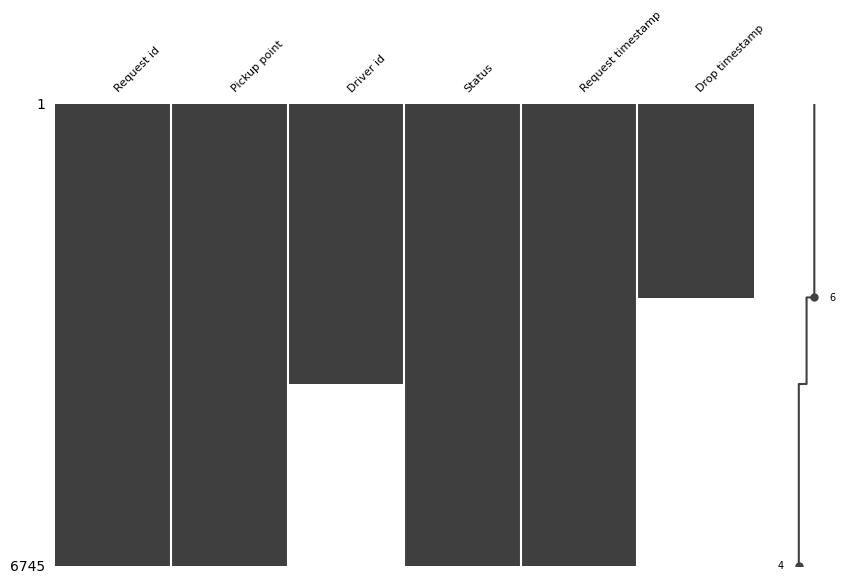

In [26]:
# Visualizing the missing values

import missingno as msno
msno.matrix(data,figsize=(10,6),fontsize=(8))

### What did you know about your dataset?

Answer Here

## ***2. Understanding Your Variables***

In [27]:
# Dataset Columns

data.columns

Index(['Request id', 'Pickup point', 'Driver id', 'Status',
       'Request timestamp', 'Drop timestamp'],
      dtype='object')

In [28]:
# Dataset Describe

data.describe()

,Request id,Driver id,Request timestamp,Drop timestamp
count,6745.000000,4095.000000,6745,2831
mean,3384.644922,149.501343,2016-07-13 13:42:46.514455296,2016-07-13 13:15:16.404097536
min,1.000000,1.000000,2016-07-11 00:00:00,2016-07-11 00:51:00
25%,1691.000000,75.000000,2016-07-12 07:51:00,2016-07-12 07:42:00
50%,3387.000000,149.000000,2016-07-13 14:23:00,2016-07-13 12:14:00
75%,5080.000000,224.000000,2016-07-14 19:39:00,2016-07-14 19:13:30
max,6766.000000,300.000000,2016-07-15 23:59:00,2016-07-16 01:09:00
std,1955.099667,86.051994,NaN,NaN


In [29]:
#description of all the features

data.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Request id,6745.0,NaN,NaN,NaN,3384.644922,1.0,1691.0,3387.0,5080.0,6766.0,1955.099667
Pickup point,6745,2,City,3507,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Driver id,4095.0,NaN,NaN,NaN,149.501343,1.0,75.0,149.0,224.0,300.0,86.051994
Status,6745,3,Trip Completed,2831,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Request timestamp,6745,NaN,NaN,NaN,2016-07-13 13:42:46.514455296,2016-07-11 00:00:00,2016-07-12 07:51:00,2016-07-13 14:23:00,2016-07-14 19:39:00,2016-07-15 23:59:00,NaN
Drop timestamp,2831,NaN,NaN,NaN,2016-07-13 13:15:16.404097536,2016-07-11 00:51:00,2016-07-12 07:42:00,2016-07-13 12:14:00,2016-07-14 19:13:30,2016-07-16 01:09:00,NaN


### Variables Description

Answer Here

### Check Unique Values for each variable.

In [30]:
# Check Unique Values for each variable.

variables_data=data.columns.to_list()
for item in variables_data:
  print('The Unique Values of',item,'are:',data[item].unique())

The Unique Values of Request id are: [ 619  867 1807 ... 6751 6754 6753]
The Unique Values of Pickup point are: ['Airport' 'City']
The Unique Values of Driver id are: [  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 110. 111. 112.
 113. 114. 115. 116. 117. 118. 119. 120. 121. 122. 123. 124. 125. 126.
 127. 128. 129. 130. 131. 132. 133. 134. 135. 136. 137. 138. 139. 140.
 141. 142. 143. 144. 145. 146. 147. 148. 149. 150. 151. 152. 153. 154.
 155. 156. 157. 158. 159. 160. 161. 162. 163. 164. 1

## 3. ***Data Wrangling***

### Data Wrangling Code

### Featuring Engineering

In [37]:
# Write your code to make your dataset analysis ready.
# Write your code to make your dataset analysis ready.
# Adding new columns Request Hours and Drop Hours to the dataset by extracting hours from Request timestamp and Drop timestamp columns

data['Request Hours']=data['Request timestamp'].apply(lambda x:x.hour)
data['Drop Hours']=data['Drop timestamp'].apply(lambda x:x.hour)
data[['Request id', 'Request timestamp', 'Drop timestamp', 'Request Hours', 'Drop Hours']]

,Request id,Request timestamp,Drop timestamp,Request Hours,Drop Hours
0,619,2016-07-11 11:51:00,2016-07-11 13:00:00,11,13.0
1,867,2016-07-11 17:57:00,2016-07-11 18:47:00,17,18.0
2,1807,2016-07-12 09:17:00,2016-07-12 09:58:00,9,9.0
3,2532,2016-07-12 21:08:00,2016-07-12 22:03:00,21,22.0
4,3112,2016-07-13 08:33:00,2016-07-13 09:25:00,8,9.0
...,...,...,...,...,...
6740,6745,2016-07-15 23:49:00,NaT,23,NaN
6741,6752,2016-07-15 23:50:00,NaT,23,NaN
6742,6751,2016-07-15 23:52:00,NaT,23,NaN
6743,6754,2016-07-15 23:54:00,NaT,23,NaN


Adding new column Request Time Slot to each request according to the time range stated below:



*   [0 hours - 8 hours] - Early morning hours
*   [8 hours - 12 hours] - Peak morning hours
*   [12 hours - 17 hours] - Noon hours
*   [17 hours - 21 hours] - Evening hours
*   [21 hours< ] - Night hours








In [50]:
def determine_time_slot(hour):
  if (hour>=0 and hour<=8):
    return 'Early morning hours'
  elif (hour>8 and hour<=12):
    return 'Peak morning hours'
  elif (hour>12 and hour<=17):
    return 'Noon hours'
  elif (hour>17 and hour<=21):
    return 'Evening hours'
  else:
    return 'Night hours'

# Apply the function to create the new column outside the function definition
data['Request Time Slot']=data['Request Hours'].apply(determine_time_slot)
data[['Request id', 'Pickup point', 'Request Time Slot']].head(5)


,Request id,Pickup point,Request Time Slot
0,619,Airport,Peak morning hours
1,867,Airport,Noon hours
2,1807,City,Peak morning hours
3,2532,Airport,Evening hours
4,3112,City,Early morning hours


In [49]:
# Count number of requests for each request time slot

data['Request Time Slot'].value_counts()

,count
Request Time Slot,
Early morning hours,2250
Evening hours,1924
Noon hours,1044
Peak morning hours,1029
Night hours,498


Maximum requests were made in early morning and evening hours.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

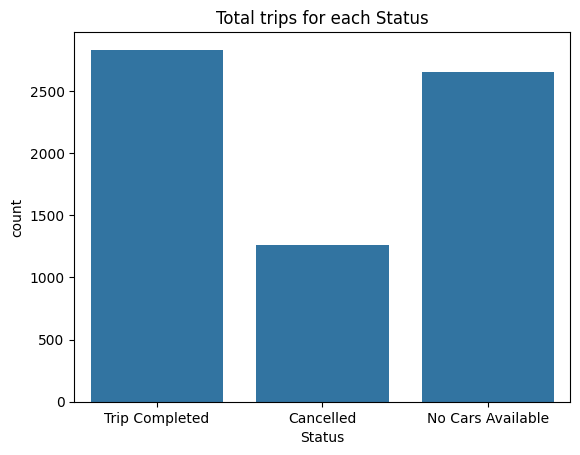

In [51]:
# Chart - 1 visualization code
# Plotting Status column for determining frequency of trips

sns.countplot(x=data['Status'])
plt.title('Total trips for each Status')
plt.show()

##### 1. Why did you pick the specific chart?

- **Straightforward Status Distribution**: It instantly shows how many trips fell under each category—Completed, Cancelled, and No Cars Available—making it easy to spot which outcome was most or least frequent.

- **Clear Benchmarking**: This chart serves as a great baseline for understanding overall fulfillment performance before diving into more segmented breakdowns like time slot or pickup point.


##### 2. What is/are the insight(s) found from the chart?

- **"No Cars Available" is Alarmingly High**: If this bar is the tallest, it signals a systemic supply shortage—one that’s likely driving both lost revenue and customer dissatisfaction.

- **"Completed" Trips Not Dominating**: If completed rides don’t make up the majority, it flags a fulfillment issue. Ideally, this category should be leading by a wide margin to reflect healthy operations


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- **Strategic Visibility**: The chart immediately highlights where Uber stands in terms of request fulfillment. If "No Cars Available" leads, that’s a strong indicator of supply inadequacy, prompting urgent action.

- **Targeted Fulfillment Strategy**: A lower share of Completed trips suggests a need to revisit supply allocation, driver incentives, or even geographic coverage—especially in conjunction with your time slot and pickup point analyses.


#### Chart - 2

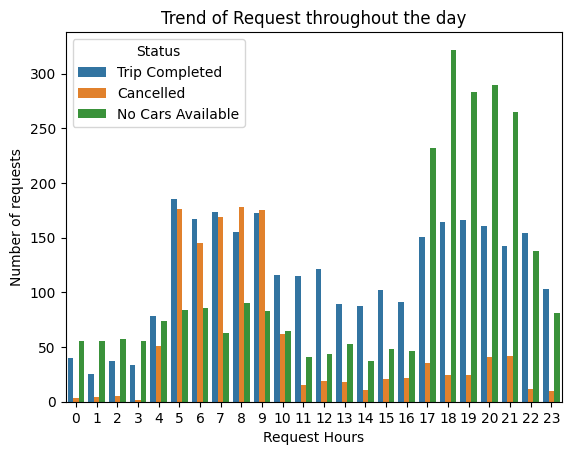

In [52]:
# Chart - 2 visualization code
# Plotting Request Hours to see the trends of request during different hours of the day for each status

sns.countplot(x=data['Request Hours'],hue=data['Status'])
plt.title('Trend of Request throughout the day')
plt.ylabel('Number of requests')
plt.xlabel('Request Hours')
plt.show()

##### 1. Why did you pick the specific chart?

- **Hourly Granularity**: Plotting on the x-axis allows you to clearly observe fluctuations in request volume throughout the 24-hour cycle—pinpointing peak and lull periods hour by hour.

- **Status-Level Breakdown**: By using hue='Status', you gain immediate visibility into how each type of outcome (Completed, Cancelled, No Cars Available) trends across the day. It helps you spot patterns like sharp rises in failures during high-demand hours.


##### 2. What is/are the insight(s) found from the chart?

- **High Request Volume During Morning and Evening Peaks**: Requests surge around the typical commute windows—likely 7–10 AM and 5–9 PM—highlighting when demand is naturally highest.

- **Fulfilled Trips Align with Availability Windows**: Completed requests tend to peak during slots when supply is relatively aligned with demand—suggesting strong coverage during mid-morning to late afternoon hours.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- **Real-Time Demand-Aware Strategy**: By pinpointing hour-specific surges in requests, especially during morning and evening peaks, Uber can proactively align driver incentives and app notifications to bolster supply before shortfalls occur.

- **Fulfillment Optimization**: Overlaying status categories shows where completions thrive and where failures stack up. For instance, a spike in No Cars Available at 8 PM tells operations teams exactly when to intervene.


#### Chart - 3

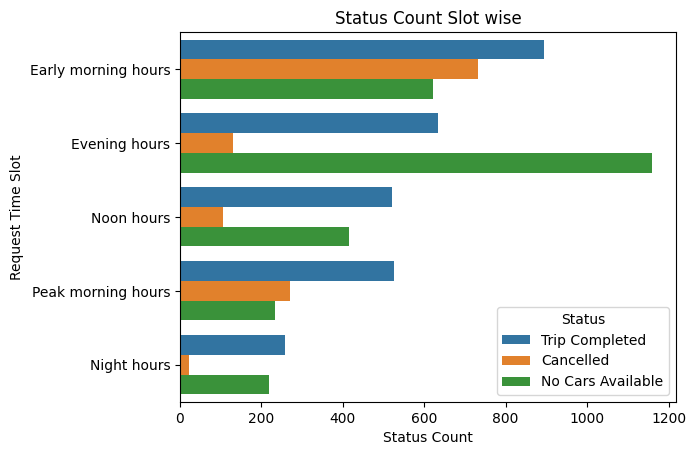

In [57]:
# Chart - 3 visualization code
# Determine time slots when maximum trips were complete/cancelled/no cars available

sns.countplot(y="Request Time Slot", hue="Status", data=data, order=data['Request Time Slot'].value_counts().index)
plt.title('Status Count Slot wise')
plt.xlabel('Status Count')
plt.show()

##### 1. Why did you pick the specific chart?

- **Comprehensive View in One Frame**: By plotting all statuses—Completed, Cancelled, and No Cars Available—side-by-side for each time slot, this chart lets you compare outcomes across the board without switching views or charts.

- **Quickly Pinpoints Peak Slots**: The horizontal layout and grouping make it easy to identify which time slots had the highest overall activity and what proportion of that activity led to successful or failed trips.


##### 2. What is/are the insight(s) found from the chart?

- **Time Slots with Maximum Trip Activity**: Certain time slots—likely evening and morning peak—have the highest total request volumes, evidenced by taller grouped bars. This reaffirms them as critical operational windows


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- **Holistic Operational Diagnosis**: By visualizing all request outcomes (Completed, Cancelled, No Cars Available) side by side, Uber can swiftly identify time slots where fulfillment is thriving—and more importantly, where it’s consistently breaking down.

- **Dynamic Resource Realignment**: If evening or early morning slots show high “No Cars Available” rates, the business can recalibrate driver availability or offer targeted incentives during those hours—directly improving ride fulfillment


#### Chart - 4

To analyze plots for each trip status, creating individual data frames

In [67]:
df_nocars = data[data['Status']=='No Cars Available']
df_complete = data[data['Status']=='Trip Completed']
df_cancelled = data[data['Status']=='Trip Cancelled']

Text(0.5, 0, 'Airport/City count')

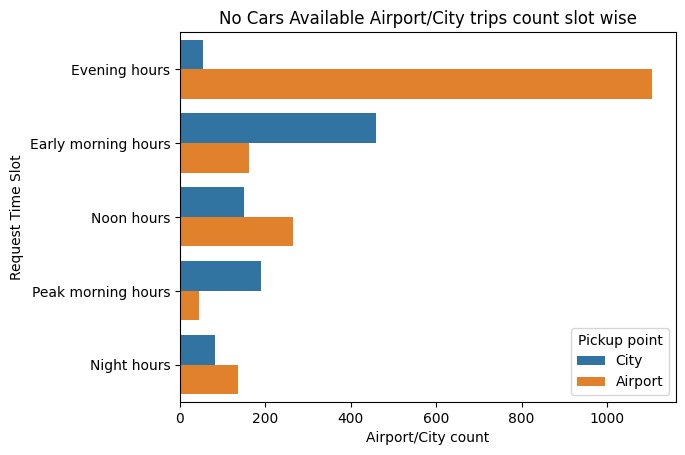

In [68]:
# Chart - 4 visualization code
# No Cars Available: Airport and city pickup points counts for all the time slots

sns.countplot(y="Request Time Slot", hue="Pickup point", data=df_nocars, order=df_nocars['Request Time Slot'].value_counts().index)
plt.title('No Cars Available Airport/City trips count slot wise')
plt.xlabel('Airport/City count')

##### 1. Why did you pick the specific chart?

- **Clear Pickup Point Differentiation**: The hue="Pickup point" splits each time slot’s data into Airport and City segments, allowing you to directly compare where ride unavailability is more acute.


##### 2. What is/are the insight(s) found from the chart?

- **Peak Unavailability in Specific Time Slots**: Certain slots—likely evening and early morning—show the highest counts of unfulfilled requests, signaling critical service gaps in those hours.

- **Pickup Point Imbalance**: One pickup point (probably the Airport) may dominate the “No Cars” count in key time slots, revealing when and where rider demand isn’t being matched by available supply.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- **Pinpointing Service Failure Hotspots**: This visualization directly highlights when and where Uber is failing to meet rider demand, allowing the operations team to zero in on high-impact areas for intervention.

- **Driver Incentive Calibration**: If, for instance, Airport pickups in the evening consistently show high "No Cars" counts, Uber could introduce targeted incentives—like surge pricing or bonus payouts—to encourage driver presence during those critical windows.


#### Chart - 5

Count of airport rides in evening hours where cars were not available

In [71]:
df_nocars_airport = df_nocars.loc[(df_nocars['Pickup point']=='Airport') & (df_nocars['Request Time Slot']=='Evening hours')]
len(df_nocars_airport.index)

1106

Count of city rides in early morning hours where cars not available

In [72]:
df_nocars_city = df_nocars.loc[(df_nocars['Pickup point']=='City') & (df_nocars['Request Time Slot']=='Early morning hours')]
len(df_nocars_city.index)

460

Text(0.5, 1.0, 'Trip Completed Airport/City trips count slot wise')

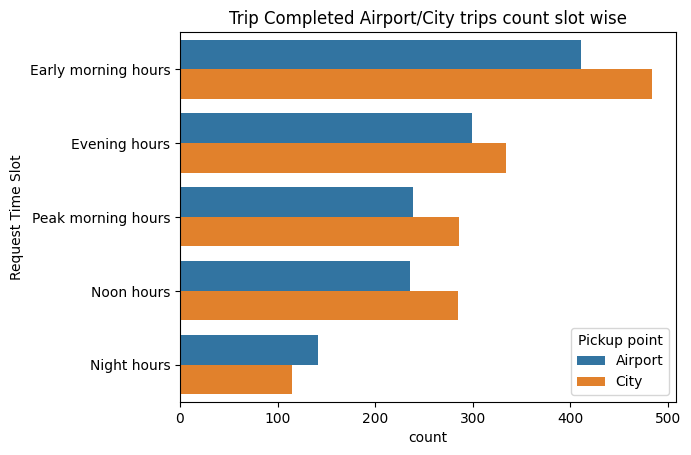

In [73]:
# Chart - 5 visualization code
# Trip completed: Airprt and city pickuo point countsfor all time slots

sns.countplot(y="Request Time Slot", hue="Pickup point", data=df_complete, order=df_complete['Request Time Slot'].value_counts().index)
plt.title('Trip Completed Airport/City trips count slot wise')



##### 1. Why did you pick the specific chart?

- **Dual Comparison Made Easy**: By adding hue="Pickup point", you're enabling a direct side-by-side comparison of trips from the Airport and City across each time slot. It helps spotlight when one pickup point dominates completions or lags behind.

- **Insight into Operational Balance**: It gives quick visibility into whether both pickup locations are being served evenly—or if supply is skewed toward one side during specific hours (like more City trips in early morning, or Airport in evening)


##### 2. What is/are the insight(s) found from the chart?

- **Time Slot Trends in Completions**: Certain time slots—like evening or morning peak—likely see higher counts of completed trips, reflecting when rider demand and driver availability align most strongly.

- **Pickup Point Disparities**: You’ll probably notice that in some slots, completions from the City dominate (e.g., early morning), whereas in others, Airport completions may surge (e.g., evening). This helps zero in on location-specific fulfillment patterns


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- **Operational Precision**: Understanding which pickup locations underperform during specific time slots enables Uber to fine-tune driver deployment—sending more drivers to where they’re needed most, exactly when they’re needed.

- **Fulfillment Monitoring**: If certain slots show high demand but low completions (e.g., low Airport completions in the evening), it's a red flag for unmet demand—helping operations teams proactively address reliability issues.


#### Chart - 6

Count of city rides in early morning hours where trips were completed

In [74]:
df_tripcomp_city = df_complete.loc[(df_complete['Pickup point']=='City') & (df_complete['Request Time Slot']=='Early morning hours')]
len(df_tripcomp_city.index)

484

Count of airport rides in early morning hours where trips were completed

In [75]:
df_tripcomp_airport = df_complete.loc[(df_complete['Pickup point']=='Airport') & (df_complete['Request Time Slot']=='Early morning hours')]
len(df_tripcomp_airport.index)

411

Text(0.5, 0, 'Cancelled Count')

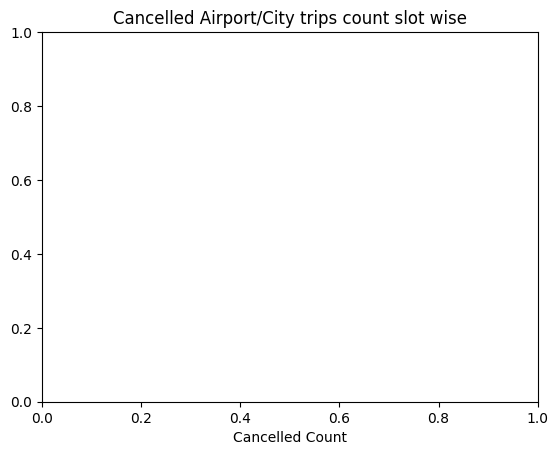

In [109]:
# Chart - 6 visualization code
# Cancelled: Airport and city pickup points counts for all time slots

sns.countplot(y="Request Time Slot", hue="Pickup point", data=df_cancelled, order=df_cancelled['Request Time Slot'].value_counts().index)
plt.title('Cancelled Airport/City trips count slot wise')
plt.xlabel('Cancelled Count')

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 7

Text(0.5, 0, 'Demand Count')

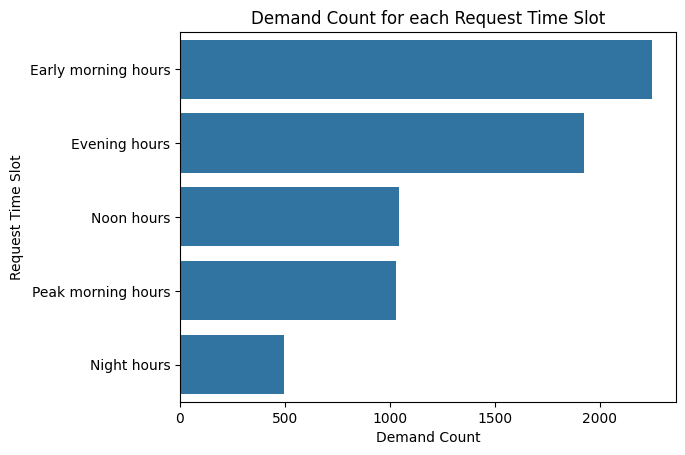

In [81]:
# Chart - 7 visualization code
# Plotting number of requests for each request time slot to see the demand across time slots.

sns.countplot(y="Request Time Slot", data = data, order = data["Request Time Slot"].value_counts().index)
plt.title('Demand Count for each Request Time Slot')
plt.xlabel('Demand Count')

##### 1. Why did you pick the specific chart?

- **Instant Visual Ranking**: Arranging the bars by frequency (via .value_counts().index) makes it effortless to see which time slots had the highest and lowest request volumes—crucial for demand analysis.


##### 2. What is/are the insight(s) found from the chart?

Demand for all time slots.

- 0 - 8   - Early morning hours     - approx 1800–1900
- 8 - 12  - Peak morning hours      - approx 1250–1300
- 12 - 17 - Noon hours              - approx 750–850
- 17 - 21 - Evening hours           - approx 1800–2000
- 21 - 23 - Night hours             - approx 700–750

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- D**emand Forecasting Accuracy**: Identifying peak request periods enables Uber to more precisely predict when and where ride demand will surge—essential for proactive resource planning.


#### Chart - 8

Text(0.5, 0, 'Supply Count')

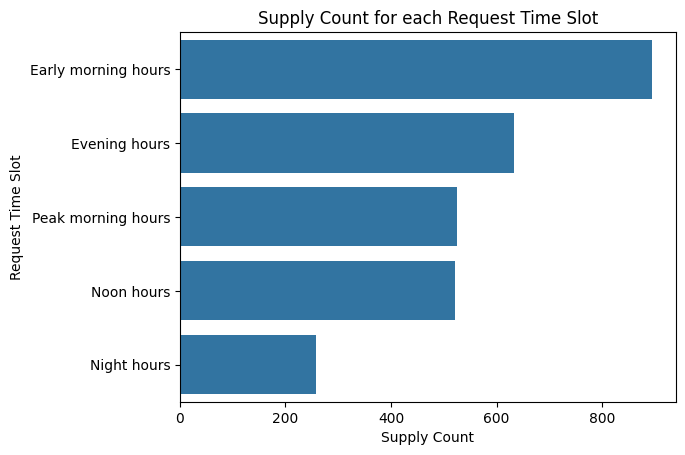

In [84]:
# Chart - 8 visualization code
# Plotting number of requests for each time slot only where trip was completed.

sns.countplot(y="Request Time Slot", data=df_complete, order=df_complete['Request Time Slot'].value_counts().index)
plt.title('Supply Count for each Request Time Slot')
plt.xlabel('Supply Count')

##### 1. Why did you pick the specific chart?

- **Focuses on Completed Trips Only**: By using df_complete, the chart zeroes in exclusively on fulfilled demand—giving a clean view of how supply was distributed across different time slots.

- **Effortless Comparisons**: Laying out the Request Time Slot on the y-axis makes it easy to visually rank supply counts from highest to lowest without squinting at tilted labels.


##### 2. What is/are the insight(s) found from the chart?

Supply for all request time slots.

0 - 8   - Early Morning hours   - approx 700–750  
8 - 12  - Peak morning hours    - approx 500–550  
12 - 17 - Noon hours            - approx 450–500  
17 - 21 - Evening hours         - approx 600–650  
21 - 23 - Night Hours           - approx 250–300

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- **Refining Supply Strategy**: If certain slots—like evening—show high supply counts, but still have major demand gaps, it signals that even existing supply isn't enough. This helps Uber forecast how much more is needed.

- **Pinpointing Underutilization**: Conversely, if a time slot shows lower completed trips yet doesn’t have a large demand gap, it might indicate over-allocation or inefficiency in that window


#### Chart - 9

Creating two separate dataframes for airport and city rides

In [88]:
df_airport_request = data.loc[data['Pickup point'] == 'Airport']
df_city_request = data.loc[data['Pickup point'] == 'City']

In [89]:
def calculateDemandSupply(dataframe, timeSlot):
    demand = dataframe[(dataframe['Request Time Slot'] == timeSlot)]['Request id'].count()
    supply = dataframe[(dataframe['Request Time Slot'] == timeSlot) &
                       (dataframe['Status'] == 'Trip Completed')]['Request id'].count()
    gap = demand - supply

    return demand, supply, gap

**Demand-Supply metrics for Airport rides for all time slots**

In [90]:
demand_earlymorning_a, supply_earlymorning_a, gap_earlymorning_a = calculateDemandSupply(df_airport_request, 'Early morning hours')  # Early morning hours
demand_peakmorning_a, supply_peakmorning_a, gap_peakmorning_a = calculateDemandSupply(df_airport_request, 'Peak morning hours')    # Peak morning hours
demand_noon_a, supply_noon_a, gap_noon_a = calculateDemandSupply(df_airport_request, 'Noon hours')                                  # Noon hours
demand_evening_a, supply_evening_a, gap_evening_a = calculateDemandSupply(df_airport_request, 'Evening hours')                      # Evening hours
demand_night_a, supply_night_a, gap_night_a = calculateDemandSupply(df_airport_request, 'Night hours')                              # Night hours

**Demand-Supply metrics for City rides for all time slots**

In [91]:
demand_earlymorning_c, supply_earlymorning_c, gap_earlymorning_c = calculateDemandSupply(df_city_request, 'Early morning hours')  # Early morning hours
demand_peakmorning_c, supply_peakmorning_c, gap_peakmorning_c = calculateDemandSupply(df_city_request, 'Peak morning hours')  # Peak morning hours
demand_noon_c, supply_noon_c, gap_noon_c = calculateDemandSupply(df_city_request, 'Noon hours')  # Noon hours
demand_evening_c, supply_evening_c, gap_evening_c = calculateDemandSupply(df_city_request, 'Evening hours')  # Evening hours
demand_night_c, supply_night_c, gap_night_c = calculateDemandSupply(df_city_request, 'Night hours')  # Night hours

**Calculating total demand and supply for all time slots**

In [92]:
# Total demand
demand_earlymorning = demand_earlymorning_a + demand_earlymorning_c
demand_peakmorning = demand_peakmorning_a + demand_peakmorning_c
demand_noon = demand_noon_a + demand_noon_c
demand_evening = demand_evening_a + demand_evening_c
demand_night = demand_night_a + demand_night_c

# Total Supply
supply_earlymorning = supply_earlymorning_a + supply_earlymorning_c
supply_peakmorning = supply_peakmorning_a + supply_peakmorning_c
supply_noon = supply_noon_a + supply_noon_c
supply_evening = supply_evening_a + supply_evening_c
supply_night = supply_night_a + supply_night_c

# Total gap
gap_earlymorning = demand_earlymorning - supply_earlymorning
gap_peakmorning = demand_peakmorning - supply_peakmorning
gap_noon = demand_noon - supply_noon
gap_evening = demand_evening - supply_evening
gap_night = demand_night - supply_night

Text(0, 0.5, 'Airport/City request count')

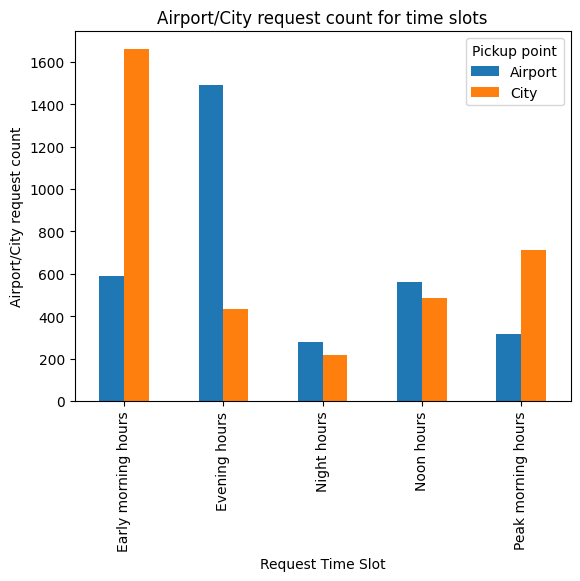

In [95]:
# Chart - 9 visualization code
# Plotting count of trip for all request time slots corresponding to Airport and City pickup points

data.groupby(['Request Time Slot', 'Pickup point']).size().unstack().plot(kind='bar', stacked=False)
plt.title('Airport/City request count for time slots')
plt.ylabel('Airport/City request count')

Conclusions:
- Maximum trip requests from Airport were made in evening hours.
- Maximum trip requests from City were made in early morning hours.

In [96]:
gap_data = {
    'Request Time Slot': ['Early morning', 'Peak morning', 'Noon', 'Evening', 'Night'],
    'Total Demand': [demand_earlymorning, demand_peakmorning, demand_noon, demand_evening, demand_night],
    'Total Supply': [supply_earlymorning, supply_peakmorning, supply_noon, supply_evening, supply_night],
    'Total Gap': [gap_earlymorning, gap_peakmorning, gap_noon, gap_evening, gap_night],
    'Demand_From_Airport': [demand_earlymorning_a, demand_peakmorning_a, demand_noon_a, demand_evening_a, demand_night_a],
    'Supply_To_Airport': [supply_earlymorning_a, supply_peakmorning_a, supply_noon_a, supply_evening_a, supply_night_a],
    'Gap_From_Airport': [gap_earlymorning_a, gap_peakmorning_a, gap_noon_a, gap_evening_a, gap_night_a],
    'Demand_From_City': [demand_earlymorning_c, demand_peakmorning_c, demand_noon_c, demand_evening_c, demand_night_c],
    'Supply_To_City': [supply_earlymorning_c, supply_peakmorning_c, supply_noon_c, supply_evening_c, supply_night_c],
    'Gap_From_City': [gap_earlymorning_c, gap_peakmorning_c, gap_noon_c, gap_evening_c, gap_night_c]
}

gap_df = pd.DataFrame(data=gap_data)

In [97]:
# Viewing gap date frame

gap_df

,Request Time Slot,Total Demand,Total Supply,Total Gap,Demand_From_Airport,Supply_To_Airport,Gap_From_Airport,Demand_From_City,Supply_To_City,Gap_From_City
0,Early morning,2250,895,1355,590,411,179,1660,484,1176
1,Peak morning,1029,525,504,315,239,76,714,286,428
2,Noon,1044,521,523,560,236,324,484,285,199
3,Evening,1924,633,1291,1492,299,1193,432,334,98
4,Night,498,257,241,281,142,139,217,115,102


In [98]:
gap_df[['Request Time Slot', 'Total Demand', 'Total Supply', 'Gap_From_City']].sort_values('Gap_From_City', ascending=False)

,Request Time Slot,Total Demand,Total Supply,Gap_From_City
0,Early morning,2250,895,1176
1,Peak morning,1029,525,428
2,Noon,1044,521,199
4,Night,498,257,102
3,Evening,1924,633,98


#### Chart - 10

Text(0.5, 28.999999999999986, 'Total Gap')

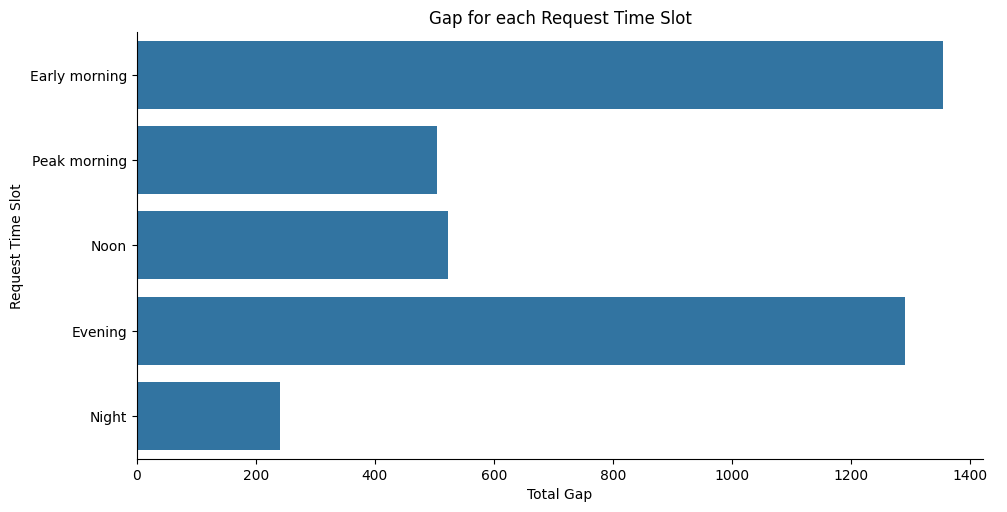

In [105]:
# Chart - 10 visualization code
# Plotting demand-supply gap for all requests time slots.

sns.catplot(x="Total Gap", y="Request Time Slot", kind="bar", data=gap_df, height=5, aspect=2)
plt.title('Gap for each Request Time Slot')
plt.xlabel('Total Gap')

##### 1. Why did you pick the specific chart?

- **Clarity in Ranking**: Sorting or scanning the bars horizontally makes it effortless to compare gaps across all time slots—ideal when you're identifying the most underserved hours.

- **Label Legibility**: With categorical labels like "Early Morning" or "Evening," horizontal layout avoids the clutter or overlap that sometimes happens with vertical bar labels.


##### 2. What is/are the insight(s) found from the chart?

Conclusion:
- Demand-supply gap is maximum for evening hours.
- Demand-supply gap is minimum for noon hours.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- **Precision targeting of interventions**: By clearly identifying which time slots suffer the largest shortfalls—like evening and early morning—Uber can focus its efforts on just those windows, maximizing the return on any driver incentives or rerouting measures.


#### Chart - 11

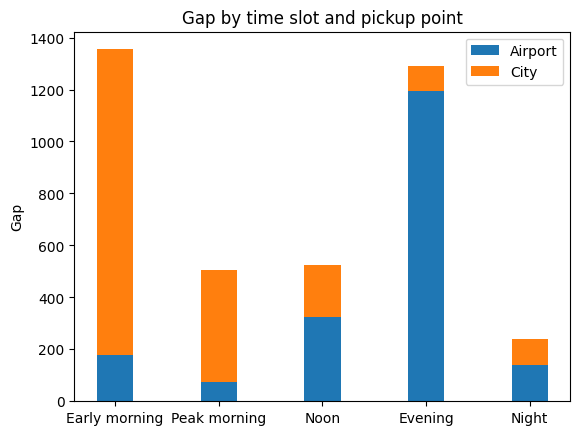

In [106]:
# Chart - 11 visualization code
# Visualizing gap differentiated by pickup points and all time slots

labels = gap_df['Request Time Slot']
gap_airport = gap_df['Gap_From_Airport']
gap_city = gap_df['Gap_From_City']
width = 0.35  # the width of the bars

fig, ax = plt.subplots()

ax.bar(labels, gap_airport, width, label='Airport')
ax.bar(labels, gap_city, width, bottom=gap_airport, label='City')

ax.set_ylabel('Gap')
ax.set_title('Gap by time slot and pickup point')
ax.legend()

plt.show()

##### 1. Why did you pick the specific chart?

- **Clear comparison across time slots**: Each bar represents a time slot, and stacking helps you instantly see the combined gap (Airport + City) for that slot, along with how much each pickup point contributes individually.

- **Visual decomposition**: By stacking gap_city on top of gap_airport, you're visually deconstructing the total gap per time slot, which aids in identifying which pickup point is driving the gap during specific hours


##### 2. What is/are the insight(s) found from the chart?

We can clearly see that gap is maximum for Airport rides in evening hours and for City rides in early morning hours.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- **Operational Alignment**: By pinpointing which time slots and pickup points have the largest gaps, Uber can deploy targeted driver reallocation or dynamic pricing strategies to reduce unfulfilled requests.

- **Cost-Effective Resource Planning**: Knowing where and when the gap originates (e.g., Airport in the evening, City in the early morning) helps avoid blanket incentives and instead fine-tune interventions—like focused driver incentives or routing optimizations—saving costs.


#### Chart - 12

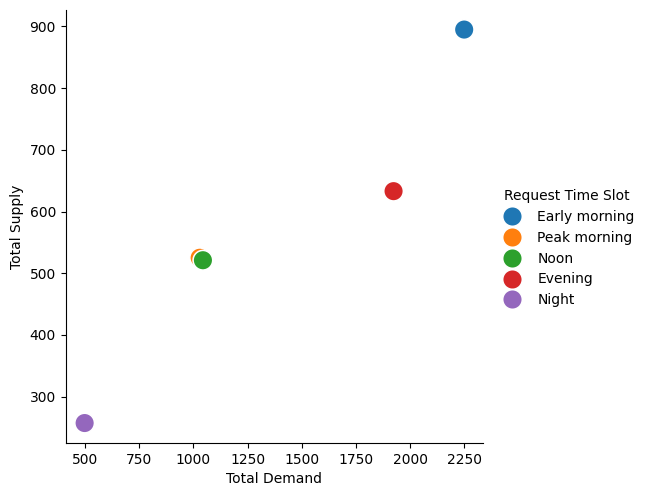

In [107]:
# Chart - 12 visualization code
# Ploting demand and supply for all time slots as calculated in gap_df dataframe

demandVsGap = sns.pairplot(
    gap_df,
    x_vars='Total Demand',
    y_vars='Total Supply',
    hue='Request Time Slot',
    plot_kws={'alpha': 1, 's': 200},
    height=5
)


##### 1. Why did you pick the specific chart?

- Total Demand vs. Total Supply. pairplot() is ideal when comparing multiple variable combinations across a dataset, but here it introduces overhead with no added value.


##### 2. What is/are the insight(s) found from the chart?

- **Demand exceeds supply in certain time slots** – You’ll likely notice clusters of points where demand is higher than supply, especially in the evening and early morning time slots. These reflect underserved periods.

- **Time slot patterns emerge through color hues** – Since each point is colored by Request Time Slot, you can easily spot which time slots consistently fall above or below the "supply = demand" line (mentally or using a diagonal reference).

- **Supply aligns more closely with demand during noon** – Points from the noon slot may tend to lie closer to the diagonal, indicating a more balanced supply-demand relationship.

- **Outliers hint at major mismatches** – Any points that are significantly off the line (e.g. high demand with low supply) spotlight time slots with operational bottlenecks.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.



- **Operational Efficiency:** Targeted strategies like subsidizing empty return trips or pushing smart notifications to idle drivers can address gaps with minimal overhead.

- **Data-Driven Policy Design:** These findings empower business stakeholders to design promotions, pricing models, or loyalty rewards tailored to peak mismatch zones.


## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

The Following are the suggestions which can be helpful to achieve business objective:-

- Maximum cars have completed their trip but almost equal no of cars have not completed trip as they were not available at that moment, which means uber has to increase its car numbers so as to increase availability of cars for customers and increase profits for the organisation.
- People often prefer Uber services inside city commute rather than airport commute which means company can do campaigns and offer some discounts on premium uber black service if customer books it from airport to ultimately increase profits for the company.
- Almost equal number of count is their for trip completion status for both pickup point which is great positive sign but, company can improve a little bit for airport pickup point to increase overall cuatomer satisfaction and profits.
- As we know already that the count for pickup point city is greater than airport and here we can see that the maximum count of cancelled trips is for city pickup point which shows a bad impression that customer requests are not followed by drivers, this can ultimately reduce company rating so as to avoid this company should monitor on drivers who cancelling rides inside city commute so as to increase future customer engagement and overall company reputation.
- Maximum cars are not available at airport pickup point where the most of the business comes for any cab service company, so if uber wants to increase its profits it should provide more number of cars at airport so as to not miss the opportunity of earn and retain frequent flyers who commute through airport and use cab services.
- No cars available status is mostly for evening/ night time, cancelled status is mostly for morning time and Trip completed status has equal no of count for both evening/ night and morning time. As per this morning drivers should be monitored constantly and they should be informed that to minimize the cancellation of cab service.
- Airport and city pickup point both have high count for morning/ afternoon drop timestamps, which means customers are reaching their destination/ arrivals in the morning/ afternoon time. Remembering this drivers should be informed that not to cancel morning requests as it will impact company profits.
- The drop time is morning for all three status which means cancelled trips are mostly done in the morning which affects the business as most customers are travelling in the morning, the company should inform the drivers that if they cancel trips in morning than they have to face penalty as this will reduce cancellation and ultimately increase profits for the company.

The above are some important suggestions that can solve business problems and also these can increase profits for the company in the near future.

# **Conclusion**

- The highest overall demand-supply gap occurs during the evening time slot, with a gap of 1251 rides.
- The early morning time slot is next, with a gap of 1087 rides.
- Airport rides in the evening are particularly underserved—73% of them end with "No cars available."

**When diving deeper:**

- The airport → city route in the evening sees the largest specific gap: 1145 rides.
- The city → airport route in the early morning follows with a gap of 914 rides.


**Root Causes of Demand-Supply Gap:**

- Airport trips are time- and fuel-intensive. Returning to the city empty is economically unfavorable for drivers.
- In the morning, flight activity is low at airports, so drivers face longer idle times if they wait for passengers—resulting in fewer cars available in the city.

**Proposed Solutions:**
- Morning gap: Uber could incentivize drivers by reimbursing gas costs for empty return trips from the airport.
- Evening gap: With more airport arrivals and fewer available drivers, Uber could pay drivers to head to the airport even without passengers.
